# 比较 `standard_equidistant.elc` 与 `standard_waveguard64_equidistant.elc`

读取两个 ASA 电极文件（`.elc`），把每个电极的 label 和对应的 xyz 坐标提取成列表，并比较两者的定位差异。

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEQ_DIR = Path("/home/dilay/project2/tw/travelling_waves/tw/fft/mingmin/sequence")
FILE = SEQ_DIR / "standard_waveguard64_equidistant.elc"


In [11]:
def parse_elc(path):
    """解析 ASA .elc 电极文件，返回 (labels, coords) 其中 coords 为 Nx3 ndarray。"""
    lines = Path(path).read_text().splitlines()

    n_positions = None
    positions = []
    labels = []

    mode = None
    for line in lines:
        stripped = line.strip()
        if not stripped:
            continue
        if stripped.startswith("NumberPositions"):
            n_positions = int(stripped.split("=")[-1].strip())
            continue
        if stripped == "Positions":
            mode = "positions"
            continue
        if stripped == "Labels":
            mode = "labels"
            continue
        if mode == "positions" and len(positions) < n_positions:
            x, y, z = (float(v) for v in stripped.split())
            positions.append((x, y, z))
        elif mode == "labels" and len(labels) < n_positions:
            labels.append(stripped)

    return labels, np.array(positions)


In [12]:
labels_a, coords_a = parse_elc(FILE)

print(f"{FILE.name}: {len(labels_a)} 个电极")



standard_waveguard64_equidistant.elc: 65 个电极


## `standard_equidistant.elc` — 电极名 + xyz 列表

In [4]:
electrodes_a = [(label, tuple(xyz)) for label, xyz in zip(labels_a, coords_a)]
df_a = pd.DataFrame(coords_a, columns=["x", "y", "z"])
df_a.insert(0, "label", labels_a)
electrodes_a


[('0Z', (87.8245, -0.0, 13.6565)),
 ('1Z', (76.9711, -0.0, 47.3542)),
 ('2Z', (51.6656, -0.0, 77.9432)),
 ('3Z', (18.6706, -0.0, 95.5387)),
 ('4Z', (-21.8995, -0.0, 99.3952)),
 ('1L', (83.3535, 27.6597, 16.9347)),
 ('1R', (83.3535, -27.6597, 16.9347)),
 ('1LB', (68.4562, 50.3075, 33.4834)),
 ('1RB', (68.4562, -50.3075, 33.4834)),
 ('2L', (64.7129, 30.2248, 57.8036)),
 ('2R', (64.7129, -30.2248, 57.8036)),
 ('3L', (36.3866, 33.2276, 81.5533)),
 ('3R', (36.3866, -33.2276, 81.5533)),
 ('4L', (-1.0257, 34.6423, 93.2723)),
 ('4R', (-1.0257, -34.6423, 93.2723)),
 ('1LC', (65.7062, 63.5721, 3.1967)),
 ('1RC', (65.7062, -63.5721, 3.1967)),
 ('2LB', (41.6311, 78.0534, 33.0701)),
 ('2RB', (41.6311, -78.0534, 33.0701)),
 ('1LA', (22.8709, 68.2678, 64.592)),
 ('1RA', (22.8709, -68.2678, 64.592)),
 ('1LD', (49.2067, 71.9482, -33.0758)),
 ('1RD', (49.2067, -71.9482, -33.0758)),
 ('2LC', (30.7762, 90.166, -6.2986)),
 ('2RC', (30.7762, -90.166, -6.2986)),
 ('3LB', (-2.1167, 93.2051, 34.301)),
 ('3RB',

In [5]:
df_a

,label,x,y,z
0,0Z,87.8245,-0.0000,13.6565
1,1Z,76.9711,-0.0000,47.3542
2,2Z,51.6656,-0.0000,77.9432
3,3Z,18.6706,-0.0000,95.5387
4,4Z,-21.8995,-0.0000,99.3952
...,...,...,...,...
60,4LC,-60.2154,84.4588,-17.8386
61,4RC,-60.2154,-84.4588,-17.8386
62,4LB,-49.8487,88.0386,25.6631
63,4RB,-49.8487,-88.0386,25.6631


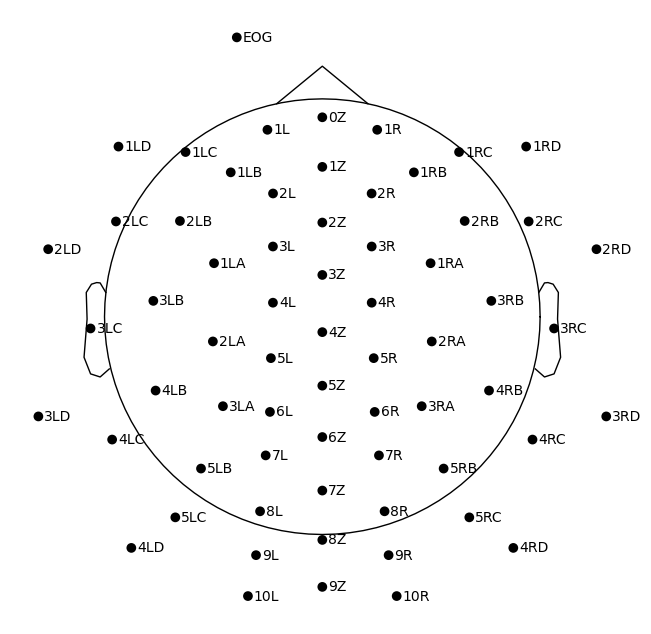

Text(0.5, 0.98, 'standard_waveguard64_equidistant.elc')

In [13]:
import mne
montage = mne.channels.read_custom_montage(FILE)
def rotate_montage_nose_up(montage):
    ch_pos = montage.get_positions()['ch_pos']
    rotated = {name: np.array([-p[1], p[0], p[2]]) for name, p in ch_pos.items()}
    return mne.channels.make_dig_montage(ch_pos=rotated, coord_frame='head')

montage_a_rot = rotate_montage_nose_up(montage)
fig = montage_a_rot.plot(kind='topomap', show_names=True, sphere='auto')
fig.suptitle(FILE.name)


## Michael 数据集(`Data/Micheal_Data_exp2`)的电极定位图

这批数据的电极定位不是单独的 `.elc`/`.ced` 文件,而是内嵌在每个 FieldTrip `.mat` 文件里的 `ft_mem.elec`(`label` + `elecpos`,单位 mm)。坐标约定和前面的 ASA `.elc` 一致:`x`=前后(正值朝前)、`y`=左右(正值朝左)、`z`=上下(正值朝上)。用同一个 `rotate_montage_nose_up` 思路(只旋转坐标,交给 MNE 自己画头形)来画。

In [6]:
from scipy.io import loadmat

MICHEAL_MAT = Path("/home/dilay/project2/tw/Data/Micheal_Data_exp2/MemImp3_mem_whole_sess1_2.mat")

def peel_to_str(x):
    while isinstance(x, np.ndarray):
        x = x.item() if x.size == 1 else x.ravel()[0]
    return str(x)

eeg = loadmat(MICHEAL_MAT, struct_as_record=False)
ft_data = eeg["ft_mem"].item()
channel_info = ft_data.elec.item()

labels_m = [peel_to_str(x) for x in np.asarray(channel_info.label).ravel()]
print(labels_m)
elecpos_m = np.asarray(channel_info.elecpos)

# VEOG/HEOG have no real scalp position (stored as (0, 0, 0)) -> drop them for the layout plot
has_position = ~np.all(elecpos_m == 0, axis=1)
labels_m_pos = [lab for lab, keep in zip(labels_m, has_position) if keep]
coords_m = elecpos_m[has_position]

print(f"{MICHEAL_MAT.name}: {len(labels_m)} 个通道, 其中 {len(labels_m_pos)} 个有头皮位置")
print("无位置的通道:", [lab for lab, keep in zip(labels_m, has_position) if not keep])


['Fpz', 'Fz', 'FCz', 'Cz', 'CPz', 'Pz', 'POz', 'Oz', 'Fp1', 'AF3', 'F1', 'FC1', 'C1', 'CP1', 'P1', 'PO3', 'O1', 'AF7', 'F7', 'FT7', 'T7', 'TP7', 'P7', 'PO7', 'F5', 'F3', 'FC5', 'FC3', 'C5', 'C3', 'CP5', 'CP3', 'P5', 'P3', 'Fp2', 'AF4', 'F2', 'FC2', 'C2', 'CP2', 'P2', 'PO4', 'O2', 'AF8', 'F8', 'FT8', 'T8', 'TP8', 'P8', 'PO8', 'F4', 'F6', 'FC4', 'FC6', 'C4', 'C6', 'CP4', 'CP6', 'P4', 'P6', 'VEOG', 'HEOG']
MemImp3_mem_whole_sess1_2.mat: 62 个通道, 其中 60 个有头皮位置
无位置的通道: ['VEOG', 'HEOG']


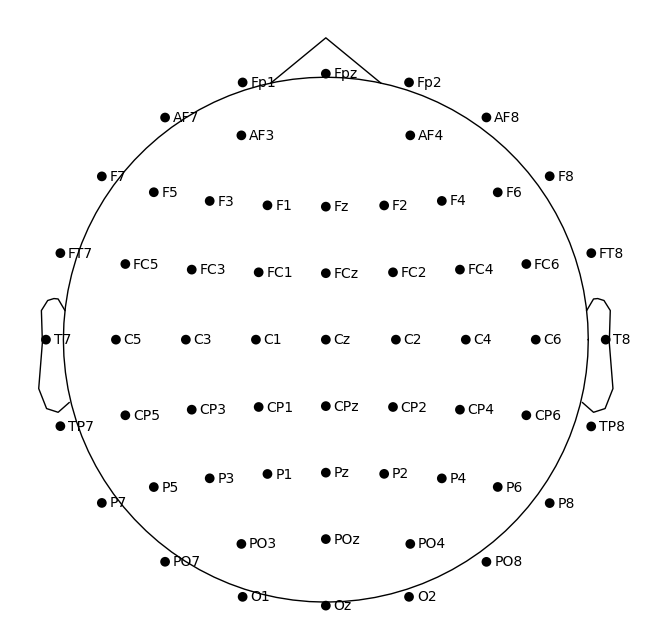

Text(0.5, 0.98, 'Micheal_Data_exp2 — MemImp3_mem_whole_sess1_2.mat')

In [16]:
ch_pos_m = {lab: pos / 1000.0 for lab, pos in zip(labels_m_pos, coords_m)}  # mm -> m for MNE DigMontage
montage_m = mne.channels.make_dig_montage(ch_pos=ch_pos_m, coord_frame='head')
montage_m_rot = rotate_montage_nose_up(montage_m)

fig = montage_m_rot.plot(kind='topomap', show_names=True, sphere='auto')
fig.suptitle(f"Micheal_Data_exp2 — {MICHEAL_MAT.name}")
